# Model Calibration

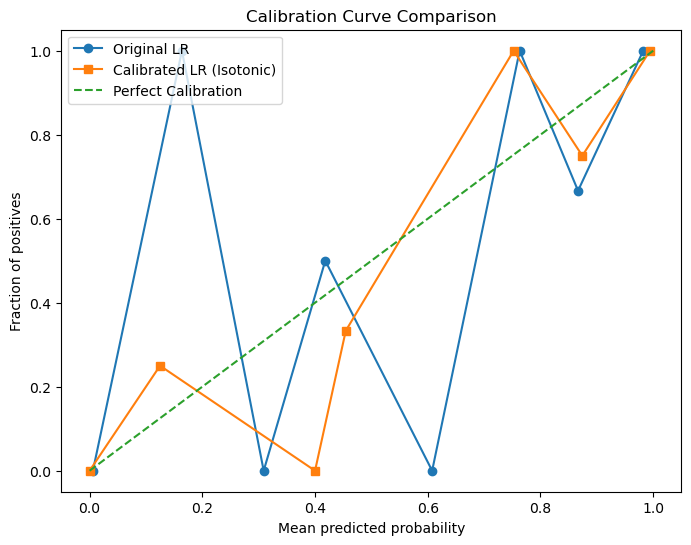

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
lr = LogisticRegression().fit(X_train, y_train)

prob_pos_lr = lr.predict_proba(X_test)[:, 1]
fraction_lr, mean_pred_lr = calibration_curve(y_test, prob_pos_lr, n_bins=10)

calibrated_clf = CalibratedClassifierCV(lr, cv='prefit', method='isotonic')
calibrated_clf.fit(X_train, y_train)
prob_pos_calibrated = calibrated_clf.predict_proba(X_test)[:, 1]
fraction_cal, mean_pred_cal = calibration_curve(y_test, prob_pos_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred_lr, fraction_lr, marker='o', label='Original LR')
plt.plot(mean_pred_cal, fraction_cal, marker='s', label='Calibrated LR (Isotonic)')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve Comparison")
plt.legend(loc="upper left")
plt.show()

# Permutation Importance

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')

In [6]:
feature_names = data.feature_names
importances = result.importances_mean
std = result.importances_std

for i, name in enumerate(feature_names):
    print(f"{name}: Mean importance = {importances[i]:.4f} (+/- {std[i]:.4f})")

sepal length (cm): Mean importance = 0.0132 (+/- 0.0177)
sepal width (cm): Mean importance = 0.0000 (+/- 0.0000)
petal length (cm): Mean importance = 0.6000 (+/- 0.0805)
petal width (cm): Mean importance = 0.1553 (+/- 0.0362)


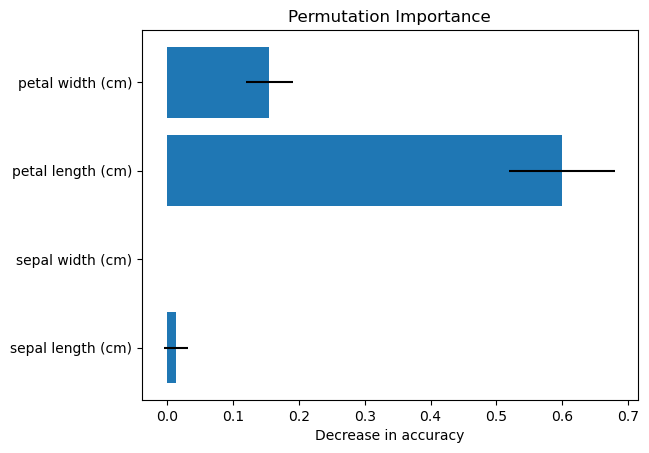

In [7]:
plt.barh(feature_names, importances, xerr=std)
plt.xlabel("Decrease in accuracy")
plt.title("Permutation Importance")
plt.show()